In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats
import random

In [2]:
semiconductors = pd.read_csv('semi_conductor_imports_2024.csv')
nato_states = pd.read_csv('Nato_Member_States.csv')

In [4]:
semiconductors['Country'] = semiconductors['Country'].str.lower()
nato_states['Country'] = nato_states['Country'].str.lower()

In [5]:
nato = set(nato_states["Country"])

In [6]:
semiconductors["In Nato"] = semiconductors["Country"].isin(nato).astype(int)

In [10]:
semiconductors["In Nato"].value_counts()

In Nato
0    190
1     32
Name: count, dtype: int64

In [11]:
semiconductors

,Continent,Continent ID,Country,Country ID,ISO 3,Trade Value,Year,In Nato
0,Africa,af,algeria,afdza,dza,4.242791e+07,2024,0
1,Africa,af,egypt,afegy,egy,2.006779e+08,2024,0
2,Africa,af,libya,aflby,lby,1.811450e+06,2024,0
3,Africa,af,morocco,afmar,mar,1.303057e+09,2024,0
4,Africa,af,sudan,afsdn,sdn,8.348756e+06,2024,0
...,...,...,...,...,...,...,...,...
217,South America,sa,paraguay,sapry,pry,3.674413e+06,2024,0
218,South America,sa,suriname,sasur,sur,6.517640e+05,2024,0
219,South America,sa,uruguay,saury,ury,4.127947e+06,2024,0
220,South America,sa,venezuela,saven,ven,2.717164e+06,2024,0


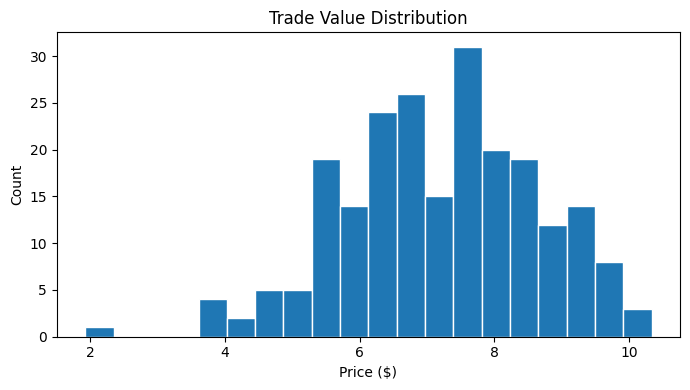

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log10(semiconductors['Trade Value']), bins=20, edgecolor='white')
ax.set_xlabel('Price ($)')
ax.set_ylabel('Count')
ax.set_title('Trade Value Distribution')
plt.tight_layout()
plt.show()

In [24]:
semiconductors['Log Trade Value'] = np.log10(semiconductors['Trade Value'])

In [20]:
def nato_diff(df):
    means = df.groupby('In Nato')['Trade Value'].mean()
    return means[1] - means[0]

In [26]:
def nato_diff_log(df):
    means = df.groupby('In Nato')['Log Trade Value'].mean()
    return means[1] - means[0]

In [27]:
observed_value = nato_diff(semiconductors)
print(f"Observed difference: {observed_value:.3f}")

observed_log_value = nato_diff_log(semiconductors)
print(f"Observed log difference: {observed_log_value:.3f}")

Observed difference: 1186950187.699
Observed log difference: 1.641


In [29]:
replicates = [observed_value]
replicates_log = [observed_log_value]
num_sim = 10000
for_simulation = semiconductors.copy()
nato_col = for_simulation['In Nato'].tolist()

for _ in range(num_sim -1):
    np.random.shuffle(nato_col)
    for_simulation['In Nato'] = nato_col
    replicates.append(nato_diff(for_simulation))
    replicates_log.append(nato_diff_log(for_simulation))

replicates = pd.DataFrame({'replicates': replicates})
replicates_log = pd.DataFrame({'replicates': replicates_log})

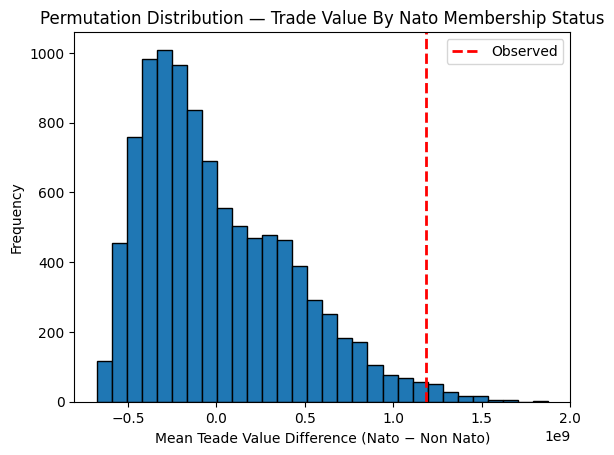

In [30]:
plt.hist(replicates['replicates'], bins=30, edgecolor='black')
plt.axvline(observed_value, color='red', linestyle='--', linewidth=2, label='Observed')
plt.xlabel('Mean Teade Value Difference (Nato − Non Nato)')
plt.ylabel('Frequency')
plt.title('Permutation Distribution — Trade Value By Nato Membership Status')
plt.legend()
plt.show()

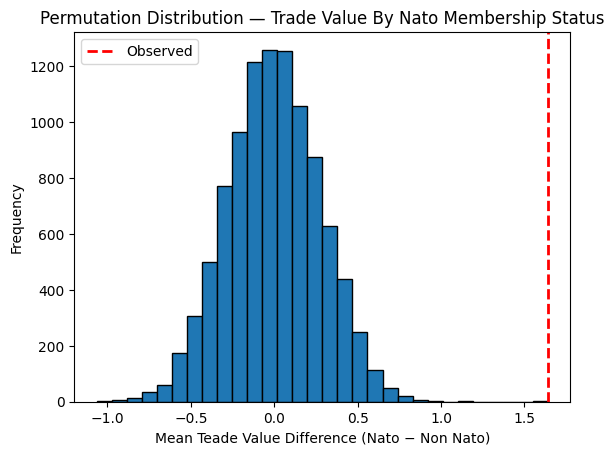

In [31]:
plt.hist(replicates_log['replicates'], bins=30, edgecolor='black')
plt.axvline(observed_log_value, color='red', linestyle='--', linewidth=2, label='Observed')
plt.xlabel('Mean Teade Value Difference (Nato − Non Nato)')
plt.ylabel('Frequency')
plt.title('Permutation Distribution — Trade Value By Nato Membership Status')
plt.legend()
plt.show()